## Brain state occupancy: p_i per state and condition

In this section, the goal is to inspect the state occupancy values p_i
for each of the K = 5 brain states, separately for each subject and condition.
The features are loaded from `features_subject_condition_k5.csv` produced by script 06
(`06_assign_states_and_we.py`).

$p_i$ tells us how often the state $i$ appears; how large a proportion of time (the windows) that falls within state $i$ (occupancy).


In [29]:
import numpy as np  # numerical operations
import pandas as pd  # tabular data handling
import matplotlib.pyplot as plt  # plotting backend
import seaborn as sns  # high-level statistical plotting
from pathlib import Path

# --------------------------------------------------------------------
# Configure plotting style for the entire notebook
# --------------------------------------------------------------------
sns.set_context("talk")  # slightly larger fonts for readability
sns.set_style("whitegrid")  # clean style suitable for scientific plots

# --------------------------------------------------------------------
# Path to the features CSV produced by the sliding_window pipeline (script 06 v2)
# --------------------------------------------------------------------
base_dir = Path("../data/processed/v2")
features_csv = str(base_dir / "features_subject_condition_k5.csv")  # path relative to this notebook

print("Loading features from:", features_csv)  # quick sanity check of the path

# --------------------------------------------------------------------
# Load the per-subject×condition features table
# --------------------------------------------------------------------
feat_df = pd.read_csv(features_csv)  # read CSV into a DataFrame

print("DataFrame shape:", feat_df.shape)  # (n_rows, n_columns) for a quick overview
feat_df.head()  # display the first few rows to inspect column names


Loading features from: ..\data\processed\v2\features_subject_condition_k5.csv
DataFrame shape: (369, 13)


,subject,condition,p_0,p_1,p_2,p_3,p_4,WE,WE_raw,H_occ,H_occ_norm,n_windows,condition_name
0,0,19,0.0,0.0,0.000000,0.000000,1.000000,0.742911,1.905529,0.000000,0.000000,174,Familiar voice
1,0,32,0.0,0.0,0.045977,0.000000,0.954023,0.744663,1.910024,0.186495,0.115876,174,Medical staff
2,0,35,0.0,0.0,0.001492,0.000000,0.998508,0.742968,1.905674,0.011200,0.006959,2681,Other
3,0,37,0.0,0.0,0.013521,0.000000,0.986479,0.743426,1.906850,0.071616,0.044498,1849,Resting
4,0,53,0.0,0.0,0.293333,0.213333,0.493333,0.788077,2.021378,1.037911,0.644890,75,der gives medicin


In [30]:
# --------------------------------------------------------------------
# Identify the condition column robustly
# --------------------------------------------------------------------
# IMPORTANT: The sliding dataset CSV can contain MANY event labels in 'condition_name'.
# But the stats/plots in this notebook assume the 3 main conditions:
#   Resting / Familiar voice / Medical staff
#
# Therefore, if those labels are present among many others, we *restrict the analysis*
# to rows that belong to these 3 conditions (one row per subject×condition).

expected_conditions = ["Resting", "Familiar voice", "Medical staff"]


def restrict_to_expected_conditions(df: pd.DataFrame, condition_name_col: str) -> tuple[pd.DataFrame, str]:
    """
    If condition_name_col contains any of the expected conditions, create a derived column
    that keeps only those 3 labels and drop everything else for downstream analysis.
    Returns (filtered_df, cond_col_to_use).
    """
    vals = df[condition_name_col].dropna().astype(str).str.strip()
    overlap = set(vals.unique()).intersection(expected_conditions)
    if len(overlap) == 0:
        return df, condition_name_col  # nothing to do
    df = df.copy()
    df["condition_3"] = df[condition_name_col].where(df[condition_name_col].isin(expected_conditions), np.nan)
    kept = int(df["condition_3"].notna().sum())
    dropped = int(df.shape[0] - kept)
    if kept == 0:
        return df, condition_name_col
    if dropped > 0:
        print(f"[info] Restricting analysis to 3 conditions; dropping {dropped} rows outside {expected_conditions}.")
    df = df.loc[df["condition_3"].notna()].copy()
    return df, "condition_3"


def pick_condition_column(df: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    # 1) Best case: condition_name exists (either already 3-level, or event-style that we can restrict)
    if "condition_name" in df.columns:
        df2, col = restrict_to_expected_conditions(df, "condition_name")
        return df2, col

    # 2) If numeric condition codes exist, optionally map common {0,1,2} -> expected labels
    if "condition" in df.columns:
        vals = df["condition"].dropna()
        uniq = set(pd.unique(vals))
        if uniq.issubset({0, 1, 2}) and len(uniq) >= 2:
            mapping = {0: "Resting", 1: "Familiar voice", 2: "Medical staff"}
            df = df.copy()
            df["condition_3"] = df["condition"].map(mapping)
            df = df.loc[df["condition_3"].notna()].copy()
            return df, "condition_3"
        return df, "condition"

    raise ValueError("No usable condition column found (expected 'condition_name' and/or 'condition').")


feat_df, cond_col = pick_condition_column(feat_df)
print("Using condition column:", cond_col)
print("Unique labels in cond_col:", feat_df[cond_col].nunique())
print("Counts per condition:")
display(feat_df[cond_col].value_counts())

# --------------------------------------------------------------------
# Collect p_i columns corresponding to state occupancies
# --------------------------------------------------------------------
p_cols = [c for c in feat_df.columns if c.startswith("p_")]  # select all occupancy columns
p_cols = sorted(p_cols)  # ensure stable order (p_0, p_1, ..., p_4)

print("Occupancy columns:", p_cols)  # sanity check of the occupancy column names

# --------------------------------------------------------------------
# Reshape to long format: one row per subject×condition×state
# --------------------------------------------------------------------
df_states_long = feat_df.melt(
    id_vars=["subject", cond_col],  # keep subject and condition as identifiers
    value_vars=p_cols,              # unpivot the p_i columns
    var_name="state_label",         # new column holding the original p_i column name
    value_name="p",                 # new column with the corresponding occupancy value
)  # result: long table with p per state

# Extract numeric state index from labels like "p_0", "p_1", ...
df_states_long["state"] = (
    df_states_long["state_label"]
    .str.replace("p_", "", regex=False)
    .astype(int)
)

print("Long-format DataFrame shape:", df_states_long.shape)
df_states_long.head(10)


[info] Restricting analysis to 3 conditions; dropping 147 rows outside ['Resting', 'Familiar voice', 'Medical staff'].
Using condition column: condition_3
Unique labels in cond_col: 3
Counts per condition:


condition_3
Familiar voice    74
Medical staff     74
Resting           74
Name: count, dtype: int64

Occupancy columns: ['p_0', 'p_1', 'p_2', 'p_3', 'p_4']
Long-format DataFrame shape: (1110, 5)


,subject,condition_3,state_label,p,state
0,0,Familiar voice,p_0,0.0,0
1,0,Medical staff,p_0,0.0,0
2,0,Resting,p_0,0.0,0
3,1,Familiar voice,p_0,0.0,0
4,1,Medical staff,p_0,0.0,0
5,1,Resting,p_0,0.0,0
6,2,Familiar voice,p_0,0.0,0
7,2,Medical staff,p_0,0.0,0
8,2,Resting,p_0,0.0,0
9,3,Familiar voice,p_0,0.0,0


**Group-level state occupancy p_i per condition**

visualising the average occupancy p_i for each of the K = 5 brain states, separately for each condition (Resting, Familiar voice, Medical staff).


State order: [0, 1, 2, 3, 4]
Condition order: ['Resting', 'Familiar voice', 'Medical staff']


C:\Users\BMOE0112\AppData\Local\Temp\ipykernel_6532\2758448377.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.barplot(


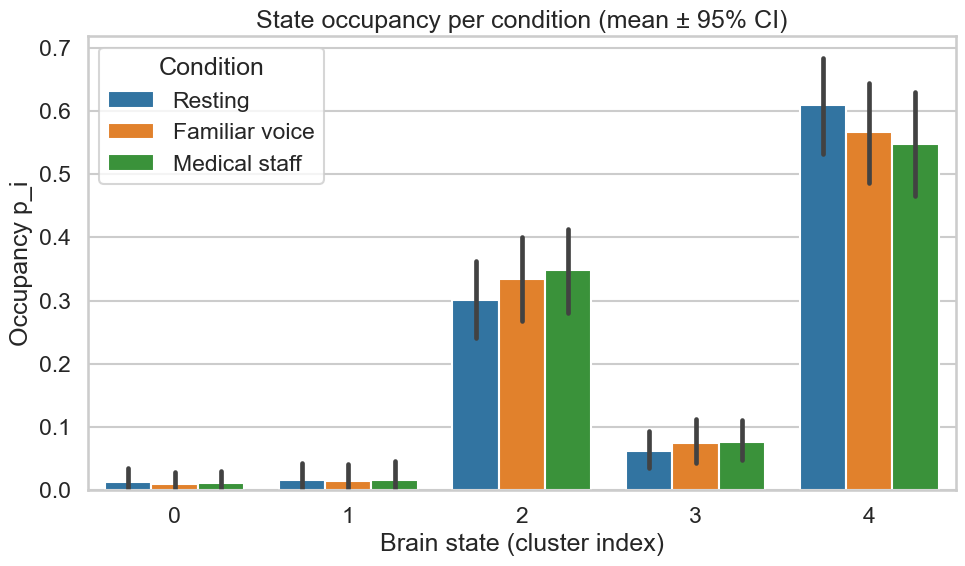

In [31]:
# --------------------------------------------------------------------
# Prepare ordering for states and conditions
# --------------------------------------------------------------------
state_order = sorted(df_states_long["state"].unique())  # ensure states are in numeric order

unique_conds = df_states_long[cond_col].unique().tolist()  # actually present labels
default_cond_order = ["Resting", "Familiar voice", "Medical staff"]  # expected labels

# Use the default ordering when it matches; otherwise fall back to observed order
cond_order = [c for c in default_cond_order if c in unique_conds]
if len(cond_order) == 0:
    cond_order = unique_conds

print("State order:", state_order)
print("Condition order:", cond_order)

# --------------------------------------------------------------------
# Barplot: mean p_i per state and condition, with 95% CI
# --------------------------------------------------------------------
plt.figure(figsize=(10, 6))  # width, height in inches

ax = sns.barplot(
    data=df_states_long,
    x="state",          # x-axis: state index (0-4)
    y="p",              # y-axis: occupancy value
    hue=cond_col,       # color-coded by condition
    order=state_order,  # enforce state order
    hue_order=cond_order,  # enforce condition order
    estimator=np.mean,  # use mean as summary statistic
    ci=95,              # 95% confidence interval
)  # create grouped barplot

ax.set_xlabel("Brain state (cluster index)")  # x-axis label
ax.set_ylabel("Occupancy p_i")  # y-axis label
ax.set_title("State occupancy per condition (mean ± 95% CI)")  # plot title

plt.legend(title="Condition")  # legend title
plt.tight_layout()  # adjust layout to avoid clipping
plt.show()  # render the figure


## State entropies $H_i$ and definition of high- and low-entropy states

In the next step, the goal is to load the entropy values $H_i$ for each of the
$K = 5$ brain states and to define two "low-entropy" and two "high-entropy"
states. These labels will later be used to compute summary measures of
state occupancy, namely:

- $p_\text{high}$: total occupancy in high-entropy states
- $p_\text{low}$: total occupancy in low-entropy states

The vector $H_i$ is loaded from `state_entropies_k5.npy` generated together
with the other features in script 06.

$H_i$ only depends on how the wSMI values are distributed within the cluster; the entropy of the connectivity pattern within state $i$.

In [32]:
import os  # used to derive paths relative to features_csv

# --------------------------------------------------------------------
# Load state entropies H_i (one value per state)
# --------------------------------------------------------------------
features_dir = os.path.dirname(features_csv)  # folder that contains the features CSV
H_path = os.path.join(features_dir, "state_entropies_k5.npy")  # adjust name if needed

print("Loading state entropies from:", H_path)

H_vec = np.load(H_path)  # shape should be (5,) for K=5 states
print("State entropies H_i:", H_vec)

# --------------------------------------------------------------------
# Identify high- and low-entropy states
# --------------------------------------------------------------------
# Sort states by entropy value (ascending)
state_indices_sorted = np.argsort(H_vec)  # from lowest to highest H_i

low_states = state_indices_sorted[:2]   # two lowest-entropy states
high_states = state_indices_sorted[-2:] # two highest-entropy states

print("Low-entropy states:", low_states)
print("High-entropy states:", high_states)


Loading state entropies from: ..\data\processed\v2\state_entropies_k5.npy
State entropies H_i: [0.92374926 0.82943516 0.78102726 0.90221728 0.74291077]
Low-entropy states: [4 2]
High-entropy states: [3 0]


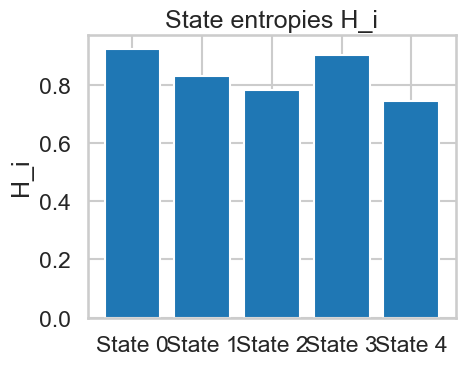

In [33]:
import matplotlib.pyplot as plt
import numpy as np

states = np.arange(len(H_vec))  # state indices 0, 1, ..., K-1

plt.figure(figsize=(5, 4))

plt.bar(states, H_vec)  # bar for each state entropy value
plt.xticks(states, [f"State {s}" for s in states])  # label x-axis with state indices
plt.ylabel("H_i")  # y-axis label for state entropy
plt.title("State entropies H_i")  # descriptive title

plt.tight_layout()
plt.show()

### Aggregate occupancy into high- and low-entropy state sets ($p_\text{high}$, $p_\text{low}$)

Given the per-state entropies $H_i$, two disjoint sets of states are defined:

- **High-entropy states**: the two states with the highest $H_i$ values.
- **Low-entropy states**: the two states with the lowest $H_i$ values.

For each subject×condition, the state occupancies $p_i$ are then aggregated into two
summary measures:

- $p_\text{high}$: summed occupancy over the high-entropy states.
- $p_\text{low}$: summed occupancy over the low-entropy states.

These quantities contrast the fraction of time the brain spends in more complex
(high-entropy) vs. more stereotyped (low-entropy) connectivity patterns.

In other words, in the cell above we sorted the states according to the state entropies -- the two lowest are called $p_{low}$ and the two highest are called $p_{high}$.


In [34]:
import numpy as np  # numerical operations

# --------------------------------------------------------------------
# Helper: aggregate occupancy over a subset of states
# --------------------------------------------------------------------
def aggregate_occupancy(row, state_indices_subset):
    """
    Sum occupancy probabilities p_i over a subset of state indices for a single row.
    """
    cols = [f"p_{int(i)}" for i in state_indices_subset]  # p_i column names for the chosen states
    return row[cols].sum()  # sum of p_i over the selected states

# --------------------------------------------------------------------
# Define K and base occupancy columns p_0, ..., p_{K-1}
# --------------------------------------------------------------------
K = len(H_vec)  # number of states (should be 5)
p_cols = [f"p_{k}" for k in range(K)]  # base occupancy columns

# Use the previously computed high_states and low_states
high_entropy_states = high_states  # indices of high-entropy states
low_entropy_states = low_states    # indices of low-entropy states

# --------------------------------------------------------------------
# Compute p_high and p_low for each subject×condition
# --------------------------------------------------------------------
feat_df["p_high"] = feat_df.apply(
    lambda row: aggregate_occupancy(row, high_entropy_states),
    axis=1,
)
feat_df["p_low"] = feat_df.apply(
    lambda row: aggregate_occupancy(row, low_entropy_states),
    axis=1,
)

# --------------------------------------------------------------------
# Preview occupancy columns including p_high and p_low (first 10 rows)
# --------------------------------------------------------------------
feat_df[["subject", cond_col] + p_cols + ["p_high", "p_low"]].head(10)


,subject,condition_3,p_0,p_1,p_2,p_3,p_4,p_high,p_low
0,0,Familiar voice,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
1,0,Medical staff,0.0,0.000000,0.045977,0.000000,0.954023,0.000000,1.000000
3,0,Resting,0.0,0.000000,0.013521,0.000000,0.986479,0.000000,1.000000
6,1,Familiar voice,0.0,0.000000,0.233129,0.000000,0.766871,0.000000,1.000000
7,1,Medical staff,0.0,0.000000,0.410714,0.107143,0.482143,0.107143,0.892857
9,1,Resting,0.0,0.010072,0.151799,0.012950,0.825180,0.012950,0.976978
10,2,Familiar voice,0.0,0.000000,0.842105,0.000000,0.157895,0.000000,1.000000
11,2,Medical staff,0.0,0.000000,0.875000,0.000000,0.125000,0.000000,1.000000
13,2,Resting,0.0,0.000000,0.790323,0.001210,0.208468,0.001210,0.998790
14,3,Familiar voice,0.0,0.000000,0.112360,0.000000,0.887640,0.000000,1.000000


## Descriptive overview of WE, H_occ_norm, p_high and p_low

In this step, the four main measures (WE, H_occ_norm, p_high and p_low) are
summarised separately for each condition (Resting, Familiar voice, Medical staff).
For each condition, the mean, standard deviation and 95% confidence interval
across subjects are reported.

In [35]:
# --------------------------------------------------------------------
# Descriptive summary for WE, H_occ_norm, p_high and p_low by condition
# --------------------------------------------------------------------
import numpy as np  # numerical operations
import pandas as pd  # data handling
from IPython.display import display  # pretty table display in notebooks

# NOTE: do NOT overwrite cond_col here; it was detected earlier from feat_df columns.
# If you set it incorrectly, you'll group by the wrong labels and often get n=1 per group.

if "cond_col" not in globals():
    raise NameError("cond_col is not defined yet. Run the earlier cell that sets cond_col.")

# Metrics to summarise
metrics = ["WE", "H_occ_norm", "p_high", "p_low"]  # main metrics of interest

# --------------------------------------------------------------------
# Quick diagnostic: how many rows/subjects per condition label?
# --------------------------------------------------------------------
print("Rows per condition label (top 10):")
display(feat_df[cond_col].value_counts().head(10))

if "subject" in feat_df.columns:
    print("Unique subjects per condition label (top 10):")
    display(feat_df.groupby(cond_col)["subject"].nunique().sort_values(ascending=False).head(10))


def summarize_by_condition(df: pd.DataFrame, metric: str, condition_col: str) -> pd.DataFrame:
    """
    Compute mean, SD, SEM and 95% CI for one metric grouped by condition.

    Important: if a group has n=1, the sample standard deviation (ddof=1) is undefined,
    so std/sem/CI will be NaN. That's expected and statistically correct.
    """
    # Aggregate with subject count if available
    agg_dict = {
        "mean": (metric, "mean"),
        "std": (metric, "std"),   # pandas uses sample std (ddof=1) -> NaN when n==1
        "n": (metric, "count"),
    }
    if "subject" in df.columns:
        agg_dict["n_subjects"] = ("subject", "nunique")

    summary = df.groupby(condition_col).agg(**agg_dict).reset_index()

    # Only define SEM and CI if we have at least 2 observations in the group
    summary["sem"] = np.where(summary["n"] >= 2, summary["std"] / np.sqrt(summary["n"]), np.nan)
    summary["ci_low"] = np.where(summary["n"] >= 2, summary["mean"] - 1.96 * summary["sem"], np.nan)
    summary["ci_high"] = np.where(summary["n"] >= 2, summary["mean"] + 1.96 * summary["sem"], np.nan)

    return summary


for metric in metrics:
    print(f"\n=== Summary for {metric} (grouped by {cond_col}) ===")
    summary_tbl = summarize_by_condition(feat_df, metric, condition_col=cond_col)
    display(summary_tbl)


Rows per condition label (top 10):


condition_3
Familiar voice    74
Medical staff     74
Resting           74
Name: count, dtype: int64

Unique subjects per condition label (top 10):


condition_3
Familiar voice    74
Medical staff     74
Resting           74
Name: subject, dtype: int64


=== Summary for WE (grouped by condition_3) ===


...

,condition_3,mean,std,n,n_subjects,sem,ci_low,ci_high
0,Familiar voice,0.321499,0.167401,74,74,0.019460,0.283357,0.359640
1,Medical staff,0.341148,0.198167,74,74,0.023036,0.295996,0.386299
2,Resting,0.344422,0.180474,74,74,0.020980,0.303302,0.385542



=== Summary for p_high (grouped by condition_3) ===


,condition_3,mean,std,n,n_subjects,sem,ci_low,ci_high
0,Familiar voice,0.084628,0.177979,74,74,0.020690,0.044076,0.125179
1,Medical staff,0.086930,0.167015,74,74,0.019415,0.048877,0.124984
2,Resting,0.074408,0.157691,74,74,0.018331,0.038479,0.110337



=== Summary for p_low (grouped by condition_3) ===


,condition_3,mean,std,n,n_subjects,sem,ci_low,ci_high
0,Familiar voice,0.901172,0.209305,74,74,0.024331,0.853482,0.948861
1,Medical staff,0.896627,0.201541,74,74,0.023429,0.850707,0.942547
2,Resting,0.910050,0.193830,74,74,0.022532,0.865887,0.954213


## Distribution of WE, H_occ_norm, p_high and p_low

Before choosing statistical tests, the distributions of WE, H_occ_norm, p_high
and p_low are inspected for each condition (Resting, Familiar voice, Medical staff).
This helps to see whether the measures are approximately symmetric or clearly skewed,
and whether a non-parametric approach is more appropriate.


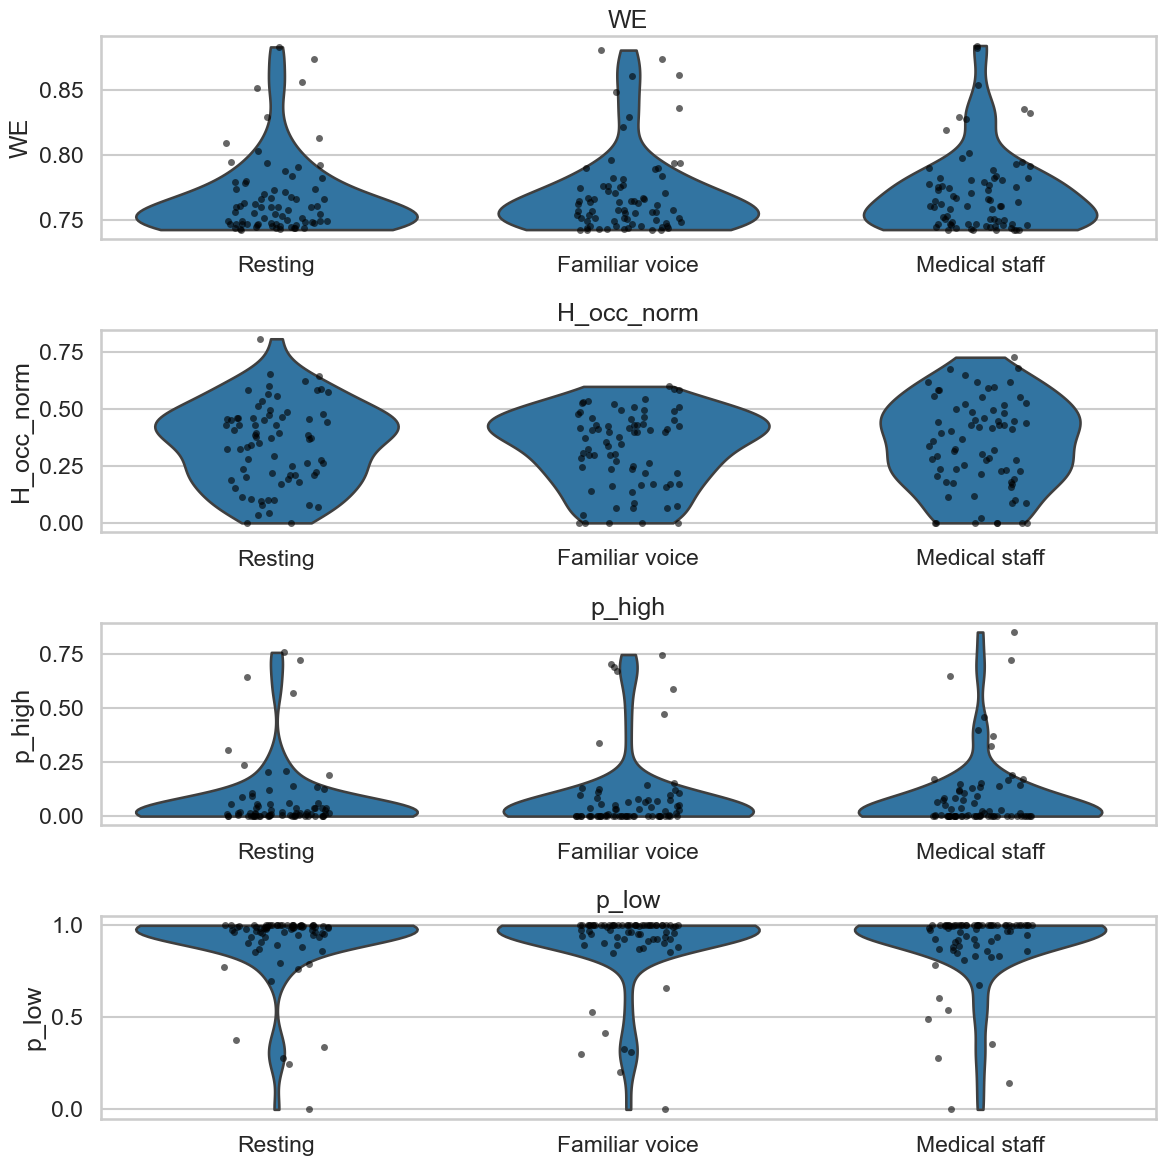

In [36]:
import matplotlib.pyplot as plt  # plotting
import seaborn as sns  # statistical plots

# Metrics to inspect
metrics = ["WE", "H_occ_norm", "p_high", "p_low"]  # main measures

if "cond_col" not in globals():
    raise NameError("cond_col is not defined yet. Run the earlier cells first.")

# Use condition order if available, otherwise infer from data
if "cond_order" in globals() and isinstance(cond_order, list) and len(cond_order) > 0:
    order = cond_order
else:
    order = feat_df[cond_col].dropna().unique().tolist()

# --------------------------------------------------------------------
# Violin + strip plots for each metric and condition
# --------------------------------------------------------------------
n_metrics = len(metrics)  # number of subplots
plt.figure(figsize=(12, 3 * n_metrics))  # width, height scaled by number of metrics

for i, metric in enumerate(metrics, start=1):
    plt.subplot(n_metrics, 1, i)  # one row per metric

    sns.violinplot(
        data=feat_df,
        x=cond_col,
        y=metric,
        order=order,
        inner=None,
        cut=0,
)

    sns.stripplot(
        data=feat_df,
        x=cond_col,
        y=metric,
        order=order,
        color="k",
        alpha=0.6,
        jitter=0.15,
)

    plt.title(metric)
    plt.xlabel("")
    plt.ylabel(metric)

plt.tight_layout()
plt.show()


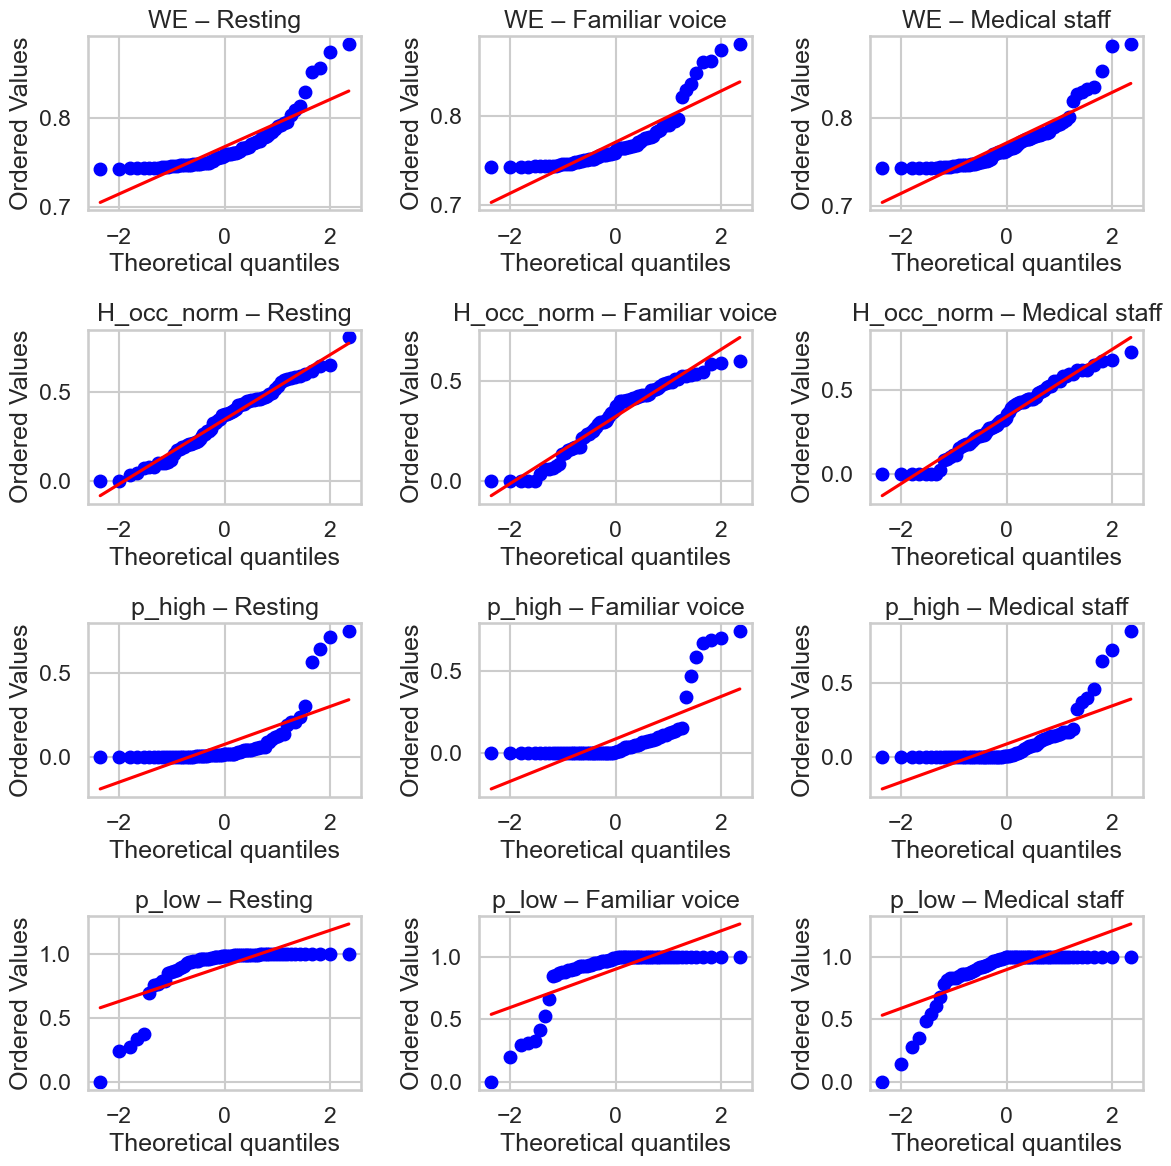

In [37]:
from scipy import stats  # for probplot
import matplotlib.pyplot as plt

metrics = ["WE", "H_occ_norm", "p_high", "p_low"]  # metrics to inspect

if "cond_col" not in globals():
    raise NameError("cond_col is not defined yet. Run the earlier cells first.")

if "cond_order" in globals() and isinstance(cond_order, list) and len(cond_order) > 0:
    order = cond_order
else:
    order = feat_df[cond_col].dropna().unique().tolist()

n_metrics = len(metrics)
n_conds = len(order)

plt.figure(figsize=(4 * n_conds, 3 * n_metrics))

for i, metric in enumerate(metrics):
    for j, cond in enumerate(order):
        ax = plt.subplot(n_metrics, n_conds, i * n_conds + j + 1)

        vals = (
            feat_df.loc[feat_df[cond_col] == cond, metric]
            .dropna()
            .values
)

        if len(vals) > 1:
            stats.probplot(vals, dist="norm", plot=ax)
            ax.get_lines()[1].set_color("red")
        else:
            ax.text(0.5, 0.5, "Not enough data", ha="center", va="center")

        ax.set_title(f"{metric} – {cond}")

plt.tight_layout()
plt.show()


## Statistical tests for WE, H_occ_norm, p_high and p_low

Based on the distributions (bounded values, visible skew and discrete steps),
non-parametric within-subject tests are used. For each measure, a Friedman test
compares the three conditions (Resting, Familiar voice, Medical staff), followed
by pairwise Wilcoxon signed-rank tests between conditions.

Friedman test:
 - A non-parametric alternative to a repeated-measures ANOVA.
 - Used when the same subjects are measured under more than two conditions.
 - It provides a single omnibus test for repeated measures without assuming normality, so you don’t have to run many separate pairwise tests (which would inflate the Type I error rate---the risk of falsely get a low p-value).

 - Used when there are more than 2 conditions (e.g. 3 brain states).
 - Used to see if there are a significanse---if yes, we continue.

 Wilcoxon signed-rank test:
  - A non-parametric alternative to the paired t-test.
  - Used for two related conditions measured on the same subjects.
  - It takes the paired differences for each subject, ranks their absolute values, and tests whether the median difference is zero.

  - Only measures to conditions at a time.
  - If we see a difference in Friedmann test, then we see WHERE are the difference.


In [38]:
from scipy import stats  # statistical tests
from statsmodels.stats.multitest import multipletests  # multiple-comparison correction
import numpy as np
import pandas as pd

if "cond_col" not in globals():
    raise NameError("cond_col is not defined yet. Run the earlier cells first.")

# Prefer the condition order discovered earlier; otherwise fall back to the expected 3 labels
default_cond_order = ["Resting", "Familiar voice", "Medical staff"]
if "cond_order" in globals() and isinstance(cond_order, list) and len(cond_order) > 0:
    cond_order = cond_order
else:
    cond_order = default_cond_order

# Validate that the expected labels are present (otherwise the repeated-measures tests are not meaningful here)
present = set(feat_df[cond_col].dropna().unique())
missing = [c for c in default_cond_order if c not in present]
if missing:
    raise ValueError(f"Missing expected conditions {missing} in {cond_col}. Present: {sorted(present)}")

metrics = ["WE", "H_occ_norm", "p_high", "p_low"]


def metric_to_wide(df: pd.DataFrame, metric: str, subject_col: str, condition_col: str, cond_order: list[str]) -> pd.DataFrame:
    """
    Convert one metric into wide format (rows = subjects, columns = conditions).
    Drops subjects with any missing condition value.
    """
    sub_df = df[[subject_col, condition_col, metric]].copy()
    wide = sub_df.pivot(index=subject_col, columns=condition_col, values=metric)
    wide = wide.reindex(columns=cond_order)
    wide = wide.dropna(axis=0, how="any")
    return wide


total_subjects = int(feat_df["subject"].nunique()) if "subject" in feat_df.columns else None
if total_subjects is not None:
    print(f"Total subjects in feat_df: {total_subjects}")
print(f"Using condition column: {cond_col}")
print(f"Condition order: {cond_order}")

for metric in metrics:
    wide = metric_to_wide(feat_df, metric, subject_col="subject", condition_col=cond_col, cond_order=cond_order)
    n = int(wide.shape[0])
    k = len(cond_order)
    dropped = (total_subjects - n) if total_subjects is not None else None
    if dropped is not None:
        print(f"\n{metric}: subjects used = {n} (dropped {dropped} due to missing condition values)")
    else:
        print(f"\n{metric}: subjects used = {n}")

    if n < 2:
        print(f"{metric}: Not enough subjects with complete data for Friedman/Wilcoxon (n={n}).")
        continue

    data_arrays = [wide[c].to_numpy() for c in cond_order]
    friedman_stat, friedman_p = stats.friedmanchisquare(*data_arrays)
    # Kendall's W (effect size) for Friedman: W = chi2 / (n * (k - 1))
    kendalls_w = float(friedman_stat) / (n * (k - 1))
    print(f"{metric}: Friedman chi2 = {friedman_stat:.3f}, p = {friedman_p:.3g}, Kendall's W = {kendalls_w:.3f}")

    pairs = [
        ("Resting", "Familiar voice"),
        ("Resting", "Medical staff"),
        ("Familiar voice", "Medical staff"),
    ]
    # Keep only pairs that exist in this dataset/order
    pairs = [(a, b) for (a, b) in pairs if a in wide.columns and b in wide.columns]
    if not pairs:
        print(f"{metric}: No valid condition pairs found in wide columns: {list(wide.columns)}")
        continue

    p_raw = []
    stats_W = []
    for c1, c2 in pairs:
        x = wide[c1].to_numpy()
        y = wide[c2].to_numpy()
        w_stat, w_p = stats.wilcoxon(x, y, alternative="two-sided")
        stats_W.append(w_stat)
        p_raw.append(w_p)

    reject, p_corr, _, _ = multipletests(p_raw, alpha=0.05, method="holm")
    for (c1, c2), W, p_unc, p_adj, rej in zip(pairs, stats_W, p_raw, p_corr, reject):
        if p_adj < 0.05:
            note = "significant after Holm"
        elif p_unc < 0.05:
            note = "trend (uncorrected p < 0.05, non-significant after Holm)"
        else:
            note = "non-significant"
        print(f"{metric}: {c1} vs {c2}: W = {W:.3f}, p = {p_unc:.4f}, p_corr = {p_adj:.4f} [{note}]")

Total subjects in feat_df: 74
Using condition column: condition_3
Condition order: ['Resting', 'Familiar voice', 'Medical staff']

WE: subjects used = 74 (dropped 0 due to missing condition values)
WE: Friedman chi2 = 0.422, p = 0.81, Kendall's W = 0.003
WE: Resting vs Familiar voice: W = 1246.000, p = 0.5656, p_corr = 0.5846 [non-significant]
WE: Resting vs Medical staff: W = 1083.000, p = 0.1949, p_corr = 0.5846 [non-significant]
WE: Familiar voice vs Medical staff: W = 1069.000, p = 0.2311, p_corr = 0.5846 [non-significant]

H_occ_norm: subjects used = 74 (dropped 0 due to missing condition values)
H_occ_norm: Friedman chi2 = 3.038, p = 0.219, Kendall's W = 0.021
H_occ_norm: Resting vs Familiar voice: W = 1066.000, p = 0.1178, p_corr = 0.3534 [non-significant]
H_occ_norm: Resting vs Medical staff: W = 1193.000, p = 0.4971, p_corr = 0.7739 [non-significant]
H_occ_norm: Familiar voice vs Medical staff: W = 1127.000, p = 0.3869, p_corr = 0.7739 [non-significant]

p_high: subjects used 

## Key results: H_occ_norm, p_high and p_low

This section shows simple visual summaries for the three main measures
that differ between conditions: H_occ_norm, p_high and p_low. For each
measure, the distribution across subjects is shown for the three
conditions (Resting, Familiar voice, Medical staff).

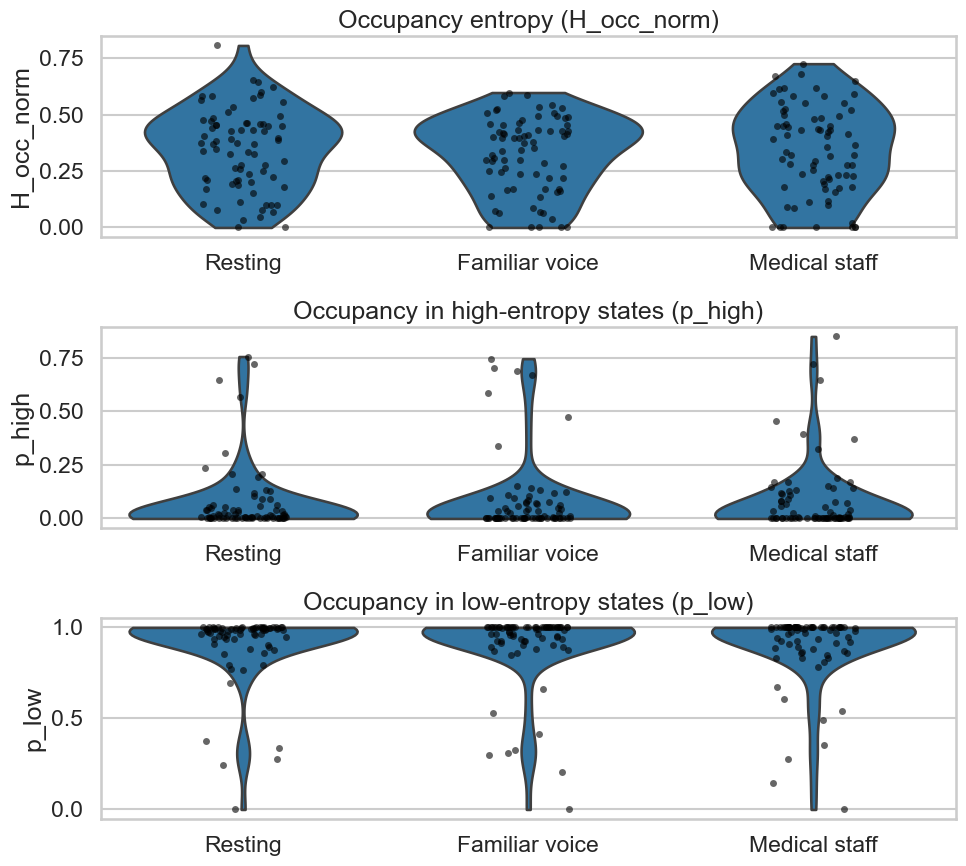

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = ["H_occ_norm", "p_high", "p_low"]
metric_titles = {
    "H_occ_norm": "Occupancy entropy (H_occ_norm)",
    "p_high": "Occupancy in high-entropy states (p_high)",
    "p_low": "Occupancy in low-entropy states (p_low)",
}

if "cond_col" not in globals():
    raise NameError("cond_col is not defined yet. Run the earlier cells first.")

if "cond_order" in globals() and isinstance(cond_order, list) and len(cond_order) > 0:
    order = cond_order
else:
    order = feat_df[cond_col].dropna().unique().tolist()

n_metrics = len(metrics_to_plot)
plt.figure(figsize=(10, 3 * n_metrics))

for i, metric in enumerate(metrics_to_plot, start=1):
    plt.subplot(n_metrics, 1, i)

    sns.violinplot(
        data=feat_df,
        x=cond_col,
        y=metric,
        order=order,
        inner=None,
        cut=0,
)

    sns.stripplot(
        data=feat_df,
        x=cond_col,
        y=metric,
        order=order,
        color="k",
        alpha=0.6,
        jitter=0.15,
)

    plt.title(metric_titles.get(metric, metric))
    plt.xlabel("")
    plt.ylabel(metric)

plt.tight_layout()
plt.show()


## Confidence interval plots for paired mean differences

The next cell shows **classical t-based** 95% confidence intervals for the *mean* of the paired differences (A − B).
If you want a plot that matches the **non-parametric** tests (Wilcoxon/Friedman), see the next plot after it, which uses **bootstrap CIs** and reports **Wilcoxon p-values**.

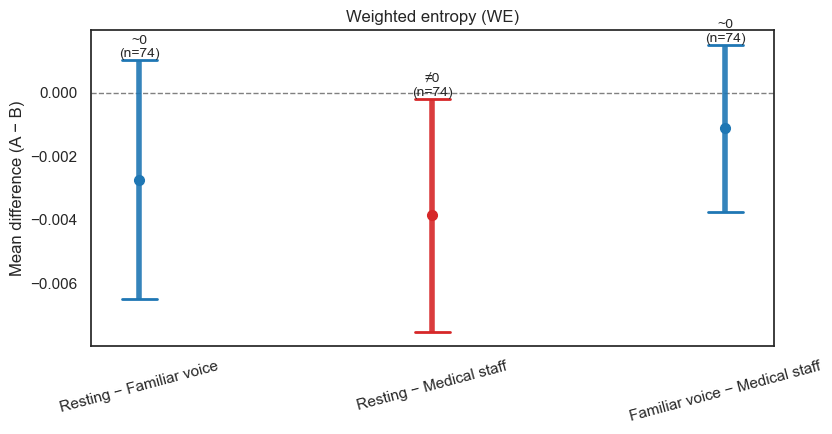

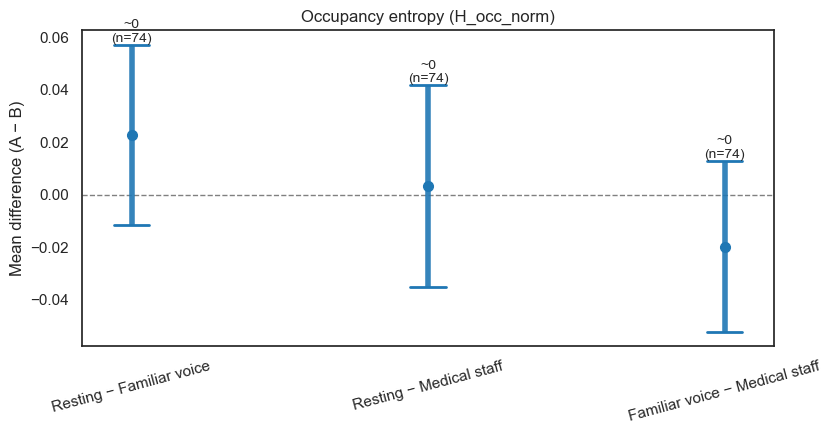

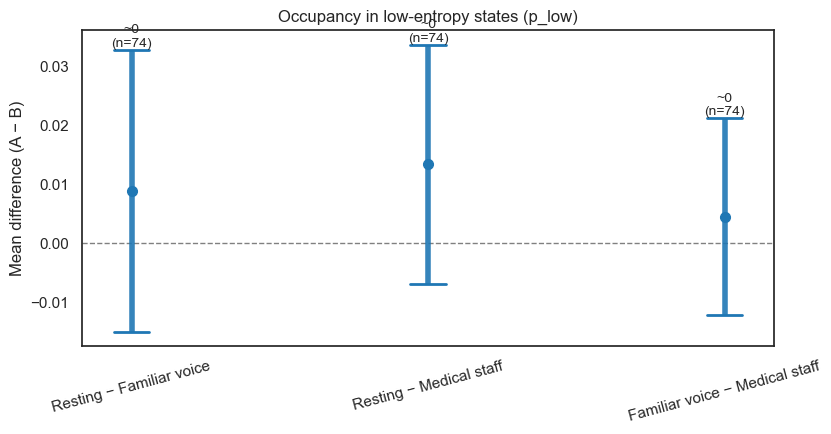

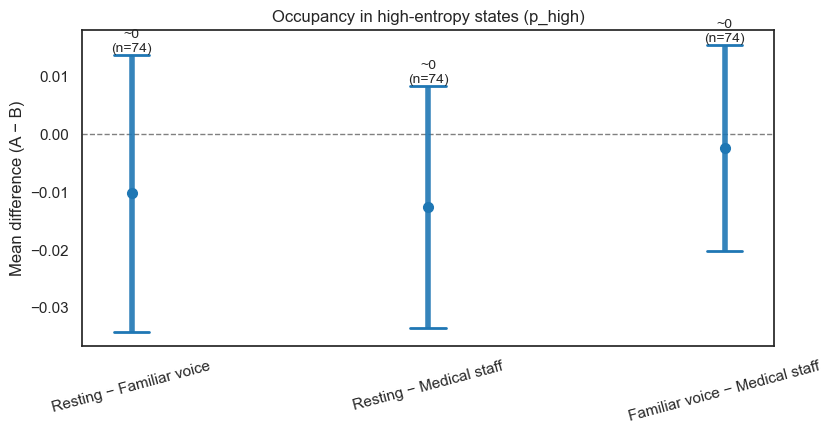

In [50]:
import numpy as np  # numerical operations
import pandas as pd  # data handling
import matplotlib.pyplot as plt  # plotting
from scipy import stats  # t-based confidence intervals

if "cond_col" not in globals():
    raise NameError("cond_col is not defined yet. Run the earlier cells first.")

# --------------------------------------------------------------------
# Helper: compute paired mean difference and t-based 95% CI (A - B)
# --------------------------------------------------------------------
def paired_mean_diff_ci(df, metric, cond_col, cond_a, cond_b, alpha=0.05):
    """
    Compute a classical t-based confidence interval for the paired mean
    difference between two conditions (cond_a - cond_b) for a given metric.

    Note: This is a parametric CI for the *mean* of the paired differences.
    """
    sub_df = df[["subject", cond_col, metric]].copy()
    wide = sub_df.pivot(index="subject", columns=cond_col, values=metric)
    wide_pair = wide[[cond_a, cond_b]].dropna()

    x_a = wide_pair[cond_a].to_numpy()
    x_b = wide_pair[cond_b].to_numpy()

    diffs = x_a - x_b
    mean_diff = float(diffs.mean())
    sd_diff = float(diffs.std(ddof=1))
    n = int(diffs.size)
    if n < 2:
        return mean_diff, np.nan, np.nan, n

    se = sd_diff / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    ci_low = mean_diff - t_crit * se
    ci_high = mean_diff + t_crit * se
    return mean_diff, float(ci_low), float(ci_high), n

# --------------------------------------------------------------------
# Metrics and condition pairs to visualise
# --------------------------------------------------------------------
metrics = ["WE", "H_occ_norm", "p_low", "p_high"]
metric_titles = {
    "WE": "Weighted entropy (WE)",
    "H_occ_norm": "Occupancy entropy (H_occ_norm)",
    "p_low": "Occupancy in low-entropy states (p_low)",
    "p_high": "Occupancy in high-entropy states (p_high)",
}

# Use the 3 expected condition labels if present; otherwise stop with a clear message
expected = ["Resting", "Familiar voice", "Medical staff"]
present = set(feat_df[cond_col].unique())
missing = [c for c in expected if c not in present]
if missing:
    raise ValueError(f"Missing expected conditions in data for paired CI plots: {missing}. Present: {sorted(present)}")

pairs = [
    ("Resting", "Familiar voice"),
    ("Resting", "Medical staff"),
    ("Familiar voice", "Medical staff"),
]
pair_labels = [f"{a} − {b}" for (a, b) in pairs]

# --------------------------------------------------------------------
# Plot CI as a "streg" + mark whether CI crosses 0
# --------------------------------------------------------------------
for metric in metrics:
    if metric not in feat_df.columns:
        print(f"[warn] Skipping {metric!r}: column not found in feat_df.")
        continue

    mean_diffs = []
    ci_lows = []
    ci_highs = []
    ns = []

    for cond_a, cond_b in pairs:
        mean_diff, ci_low, ci_high, n = paired_mean_diff_ci(
            feat_df,
            metric=metric,
            cond_col=cond_col,
            cond_a=cond_a,
            cond_b=cond_b,
            alpha=0.05,
        )
        mean_diffs.append(mean_diff)
        ci_lows.append(ci_low)
        ci_highs.append(ci_high)
        ns.append(n)

    mean_diffs = np.array(mean_diffs, dtype=float)
    ci_lows = np.array(ci_lows, dtype=float)
    ci_highs = np.array(ci_highs, dtype=float)

    x = np.arange(len(pairs))
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.axhline(0.0, color="grey", linestyle="--", linewidth=1)

    for i in range(len(pairs)):
        if not (np.isfinite(mean_diffs[i]) and np.isfinite(ci_lows[i]) and np.isfinite(ci_highs[i])):
            continue
        ci_includes_0 = bool(ci_lows[i] <= 0 <= ci_highs[i])
        color = "tab:blue" if ci_includes_0 else "tab:red"
        tag = "~0" if ci_includes_0 else "≠0"

        # CI as a thick vertical line + caps
        ax.vlines(x[i], ci_lows[i], ci_highs[i], color=color, linewidth=4, alpha=0.9)
        ax.plot([x[i] - 0.06, x[i] + 0.06], [ci_lows[i], ci_lows[i]], color=color, linewidth=2)
        ax.plot([x[i] - 0.06, x[i] + 0.06], [ci_highs[i], ci_highs[i]], color=color, linewidth=2)
        # Mean as a dot
        ax.plot(x[i], mean_diffs[i], marker="o", color=color, markersize=7)

        # Label: does CI exclude 0?
        ax.text(x[i], ci_highs[i], f"{tag}\n(n={ns[i]})", ha="center", va="bottom", fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, rotation=15)
    ax.set_ylabel("Mean difference (A − B)")
    ax.set_title(metric_titles.get(metric, metric))
    plt.tight_layout()
    plt.show()

In [48]:
import numpy as np
import pandas as pd
from scipy import stats

# --------------------------------------------------------------------
# Diagnostic: compare t-based CI vs Wilcoxon p-values (paired)
# --------------------------------------------------------------------
if "cond_col" not in globals():
    raise NameError("cond_col is not defined.")
if "feat_df" not in globals():
    raise NameError("feat_df is not defined.")

pairs = [
    ("Resting", "Familiar voice"),
    ("Resting", "Medical staff"),
    ("Familiar voice", "Medical staff"),
]

metrics = [m for m in ["WE", "H_occ_norm", "p_low", "p_high"] if m in feat_df.columns]

rows = []
for metric in metrics:
    wide = feat_df[["subject", cond_col, metric]].pivot(index="subject", columns=cond_col, values=metric)
    for a, b in pairs:
        if a not in wide.columns or b not in wide.columns:
            continue
        diffs = (wide[a] - wide[b]).dropna()
        n = int(diffs.shape[0])
        if n < 2:
            continue
        mean_diff = float(diffs.mean())
        sd = float(diffs.std(ddof=1))
        se = sd / np.sqrt(n)
        tcrit = stats.t.ppf(1 - 0.05 / 2, df=n - 1)
        ci_low = mean_diff - tcrit * se
        ci_high = mean_diff + tcrit * se
        t_p = float(stats.ttest_rel(wide[a].loc[diffs.index], wide[b].loc[diffs.index]).pvalue)
        w_stat, w_p = stats.wilcoxon(wide[a].loc[diffs.index], wide[b].loc[diffs.index], alternative="two-sided")
        rows.append({
            "metric": metric,
            "pair": f"{a} − {b}",
            "n": n,
            "mean_diff": mean_diff,
            "ci_low": float(ci_low),
            "ci_high": float(ci_high),
            "ci_includes_0": bool(ci_low <= 0 <= ci_high),
            "t_p": t_p,
            "wilcoxon_p": float(w_p),
        })

diag_tbl = pd.DataFrame(rows)
diag_tbl = diag_tbl.sort_values(["metric", "pair"]).reset_index(drop=True)
display(diag_tbl)

,metric,pair,n,mean_diff,ci_low,ci_high,ci_includes_0,t_p,wilcoxon_p
0,H_occ_norm,Familiar voice − Medical staff,74,-0.019649,-0.052128,0.012830,True,0.231820,0.386926
1,H_occ_norm,Resting − Familiar voice,74,0.022923,-0.011329,0.057176,True,0.186418,0.117805
2,H_occ_norm,Resting − Medical staff,74,0.003274,-0.035141,0.041690,True,0.865588,0.497128
3,WE,Familiar voice − Medical staff,74,-0.001117,-0.003748,0.001515,True,0.400510,0.231098
4,WE,Resting − Familiar voice,74,-0.002740,-0.006500,0.001021,True,0.150797,0.565633
5,WE,Resting − Medical staff,74,-0.003856,-0.007521,-0.000191,False,0.039465,0.194872
6,p_high,Familiar voice − Medical staff,74,-0.002302,-0.020077,0.015472,True,0.797014,0.280418
7,p_high,Resting − Familiar voice,74,-0.010220,-0.034121,0.013681,True,0.396891,0.684870
8,p_high,Resting − Medical staff,74,-0.012522,-0.033399,0.008354,True,0.235786,0.805326
9,p_low,Familiar voice − Medical staff,74,0.004545,-0.012101,0.021190,True,0.587997,0.193330


### Mean wSMI pattern for each brain state

In this step, each brain state is visualised in terms of its average wSMI
connectivity pattern. The stacked feature matrix (all windows) is combined with
the state labels to compute the mean wSMI vector for each state. These vectors
are then mapped back to (C × C) connectivity matrices using the original
channel-pair indexing and plotted as heatmaps.

The plots is an average of wSMI over all the windows for that brain state.

Stack: N=376068, P=171, channels C=19, states K=5
Windows per state: [4715, 6154, 118157, 23774, 223268]


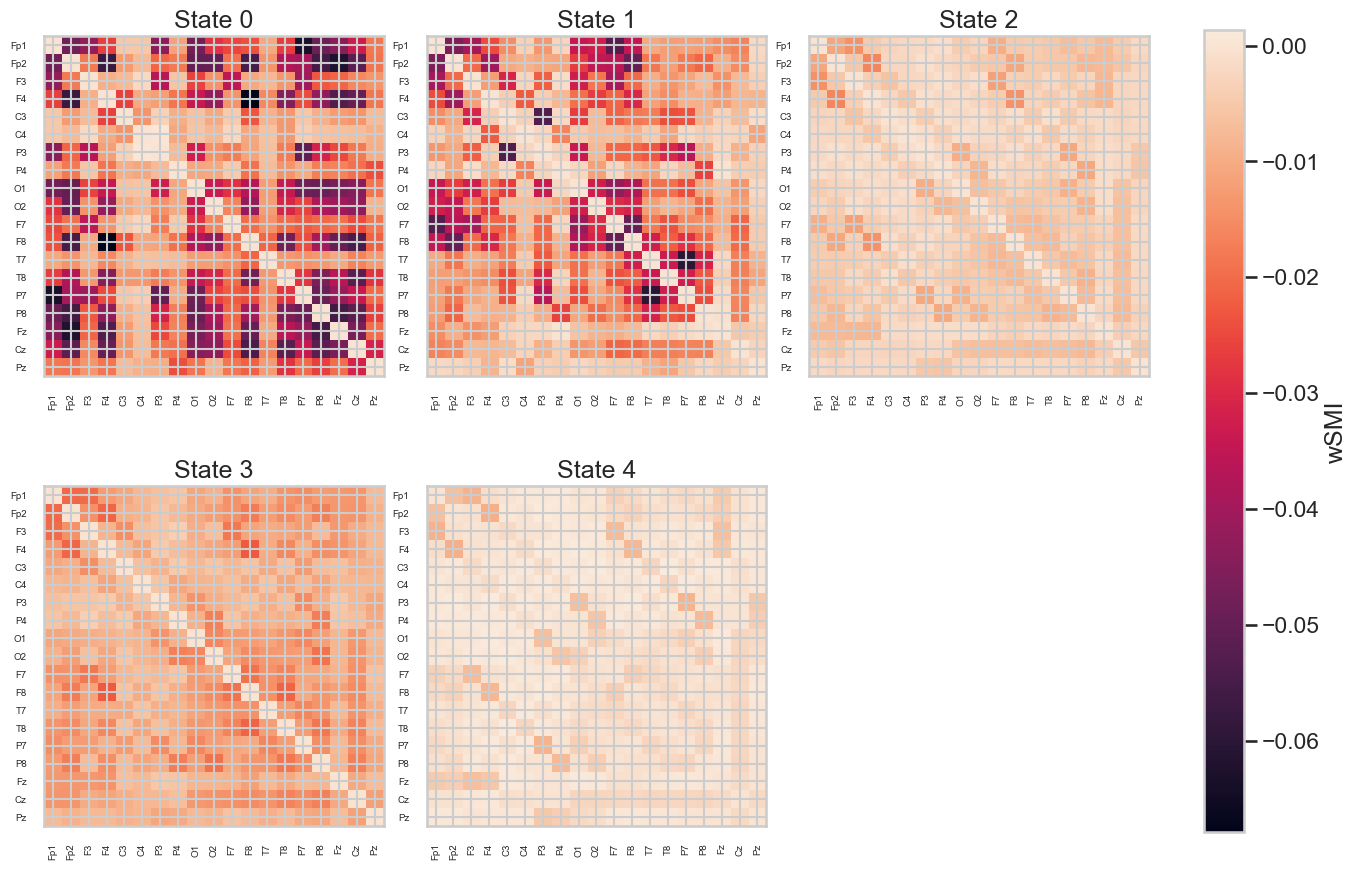

In [42]:
import json
from pathlib import Path
import numpy as np  # numerical operations
import matplotlib.pyplot as plt  # plotting

# --------------------------------------------------------------------
# Load stacked wSMI vectors + mapping, then compute mean connectivity per state
# --------------------------------------------------------------------
# This cell is intentionally self-contained (defines state_maps + ch_names).

# 1) Locate meta + labels
base_dir = globals().get("base_dir", Path("../data/processed/v2"))
base_dir = Path(base_dir)
meta_path = base_dir / "features_k5_meta.json"
labels_path = base_dir / "state_labels_k5.npy"

if not meta_path.exists():
    raise FileNotFoundError(f"Missing meta file: {meta_path}")
if not labels_path.exists():
    raise FileNotFoundError(f"Missing state labels file: {labels_path}")

with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

stack_path = Path(meta["stack"])
if not stack_path.exists():
    raise FileNotFoundError(f"Stack NPZ does not exist: {stack_path}")

state_labels = np.load(labels_path)
if state_labels.ndim != 1:
    raise ValueError(f"Expected 1D state_labels, got shape {state_labels.shape}")

# 2) Load stacked vectors and mapping paths
with np.load(stack_path, allow_pickle=False) as npz:
    X = np.asarray(npz["X"], dtype=np.float32)  # (N, P)
    pairs_idx_rel = str(npz["pairs_idx_path"])
    pairs_json_rel = str(npz["pairs_json_path"])

if X.ndim != 2:
    raise ValueError(f"Expected X to be 2D, got shape {X.shape}")
N, P = X.shape
if len(state_labels) != N:
    raise ValueError(f"Length mismatch: X has N={N} rows, but state_labels has {len(state_labels)}")

# Resolve mapping files relative to repo root (notebooks live one level down)
repo_root = Path("..").resolve()
pairs_idx_path = Path(pairs_idx_rel)
pairs_json_path = Path(pairs_json_rel)
if not pairs_idx_path.is_absolute():
    pairs_idx_path = (repo_root / pairs_idx_path).resolve()
if not pairs_json_path.is_absolute():
    pairs_json_path = (repo_root / pairs_json_path).resolve()

if not pairs_idx_path.exists():
    raise FileNotFoundError(f"pairs_idx.npy not found: {pairs_idx_path}")
if not pairs_json_path.exists():
    raise FileNotFoundError(f"pairs.json not found: {pairs_json_path}")

pairs_idx = np.load(pairs_idx_path)  # shape (2, P)
if pairs_idx.shape != (2, P):
    raise ValueError(f"Expected pairs_idx shape (2,{P}), got {pairs_idx.shape}")

with open(pairs_json_path, "r", encoding="utf-8") as f:
    pairs_json = json.load(f)  # list of [ch_a, ch_b] pairs, length P
if not isinstance(pairs_json, list) or len(pairs_json) != P:
    raise ValueError(
        f"Expected pairs.json to be a list of length {P}, got {type(pairs_json)} "
        f"with len={len(pairs_json) if hasattr(pairs_json,'__len__') else 'n/a'}"
    )

# Derive consistent channel-name ordering by matching names <-> numeric indices
name_to_idx = {}
for (ch_a, ch_b), (i, j) in zip(pairs_json, pairs_idx.T, strict=True):
    for name, idx in ((ch_a, int(i)), (ch_b, int(j))):
        if name in name_to_idx and name_to_idx[name] != idx:
            raise ValueError(f"Channel index conflict for {name!r}: {name_to_idx[name]} vs {idx}")
        name_to_idx[name] = idx

C = max(name_to_idx.values()) + 1
ch_names = [None] * C
for name, idx in name_to_idx.items():
    ch_names[idx] = name
ch_names = [x if x is not None else f"Ch{ix}" for ix, x in enumerate(ch_names)]

# 3) Compute mean vector per state, then map back to (C×C) matrices
K = int(meta.get("K", int(state_labels.max()) + 1))
K = max(K, int(state_labels.max()) + 1)
counts = np.bincount(state_labels.astype(int), minlength=K)
print(f"Stack: N={N}, P={P}, channels C={C}, states K={K}")
print("Windows per state:", counts.tolist())

state_means = np.full((K, P), np.nan, dtype=np.float32)
for k in range(K):
    mask = state_labels == k
    if int(mask.sum()) == 0:
        continue
    state_means[k] = X[mask].mean(axis=0)

state_maps = np.full((K, C, C), np.nan, dtype=np.float32)
for k in range(K):
    mat = np.full((C, C), np.nan, dtype=np.float32)
    np.fill_diagonal(mat, 0.0)
    vec = state_means[k]
    if np.all(np.isnan(vec)):
        state_maps[k] = mat
        continue
    for p in range(P):
        i, j = int(pairs_idx[0, p]), int(pairs_idx[1, p])
        v = float(vec[p])
        mat[i, j] = v
        mat[j, i] = v
    state_maps[k] = mat

# --------------------------------------------------------------------
# Plot one connectivity matrix per state
# --------------------------------------------------------------------
vmin = float(np.nanmin(state_maps))
vmax = float(np.nanmax(state_maps))

n_cols = 3
n_rows = int(np.ceil(K / n_cols))

# NOTE: do NOT share axes here; Matplotlib will otherwise hide tick labels on inner plots.
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.5 * n_cols, 4.5 * n_rows),
    constrained_layout=True,
    sharex=False,
    sharey=False,
 )
axes = np.array(axes).reshape(n_rows, n_cols)

im = None
for k in range(K):
    row = k // n_cols
    col = k % n_cols
    ax = axes[row, col]
    im = ax.imshow(state_maps[k], vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(f"State {k}")
    ax.set_xticks(range(C))
    ax.set_yticks(range(C))
    ax.set_xticklabels(ch_names, rotation=90, fontsize=7)
    ax.set_yticklabels(ch_names, fontsize=7)
    # Make sure labels are visible even when many subplots exist
    ax.tick_params(axis="x", labelbottom=True)
    ax.tick_params(axis="y", labelleft=True)

for idx in range(K, n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].axis("off")

if im is not None:
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)
    cbar.set_label("wSMI")

plt.show()

## Group-level heatmap: $P({state} \mid {event})$ (row-normalized)

This heatmap shows, for each event label, the average distribution over brain states.

**Important:** To avoid long Resting periods dominating due to having many more windows, we compute the state-occupancy vector $p_i$ **per subject×event** and then average across subjects. Each row is then (re-)normalised to sum to 1.

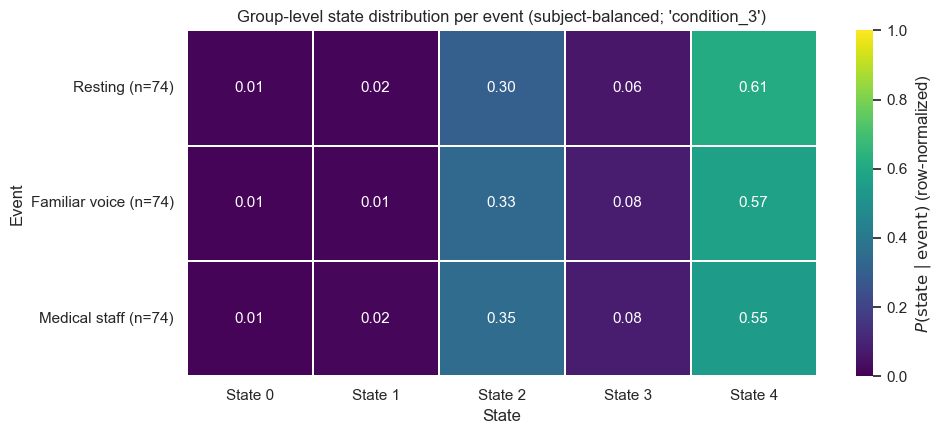

condition_3,Resting,Familiar voice,Medical staff
n_subjects,74,74,74


In [46]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Group-level heatmap: P(state | event), subject-balanced
# - Default: uses the notebook's derived 3-class column (cond_col / condition_3)
# - Set use_raw_events=True to use all raw condition_name labels (often many).
# -----------------------------------------------------------------------------
use_raw_events = False

# Prefer using the in-notebook dataframe (already has the derived 3-condition labels).
if "feat_df" in globals() and isinstance(globals()["feat_df"], pd.DataFrame):
    df_all = globals()["feat_df"].copy()
else:
    features_csv = globals().get("features_csv", None)
    if features_csv is None:
        features_csv = "data/processed/features_subject_condition_k5.csv"
    features_csv_path = Path(features_csv)
    if not features_csv_path.exists():
        raise FileNotFoundError(f"Could not find features CSV at: {features_csv_path.resolve()}")
    df_all = pd.read_csv(features_csv_path)

# Determine event/condition column
cond_col = globals().get("cond_col", None)
candidate_cols = []
if isinstance(cond_col, str):
    candidate_cols.append(cond_col)
candidate_cols += ["condition_3", "condition_name", "condition"]
candidate_cols = [c for c in candidate_cols if c in df_all.columns]
if not candidate_cols:
    raise KeyError("Could not find any event/condition column (tried cond_col/condition_3/condition_name/condition).")

if use_raw_events:
    event_col = "condition_name" if "condition_name" in df_all.columns else candidate_cols[0]
else:
    # Hard preference: the notebook's derived 3-class column, when available
    if isinstance(cond_col, str) and cond_col in df_all.columns:
        event_col = cond_col
    elif "condition_3" in df_all.columns:
        event_col = "condition_3"
    else:
        # Otherwise choose a low-cardinality *string-like* column if possible
        event_col = None
        for c in candidate_cols:
            ser = df_all[c].astype(str).str.strip().replace({"": np.nan}).dropna()
            nunique = ser.nunique()
            looks_numeric = ser.str.fullmatch(r"\d+").mean() > 0.9 if len(ser) else False
            if nunique <= 10 and not looks_numeric:
                event_col = c
                break
        if event_col is None:
            event_col = candidate_cols[0]

# Subject id column
subject_col_candidates = [c for c in ["subject", "subject_id", "sub", "participant"] if c in df_all.columns]
if not subject_col_candidates:
    raise KeyError("Could not find a subject id column (tried: subject, subject_id, sub, participant).")
subject_col = subject_col_candidates[0]

# State occupancy columns: p_0 ... p_{K-1} (avoid p_high/p_low, etc.)
p_cols = [c for c in df_all.columns if isinstance(c, str) and c.startswith("p_") and c[2:].isdigit()]
if not p_cols:
    raise KeyError("No state occupancy columns found (expected columns like p_0, p_1, ...).")
p_cols = sorted(p_cols, key=lambda s: int(s.split("_")[1]))

tmp = df_all[[subject_col, event_col] + p_cols].copy()
tmp[event_col] = tmp[event_col].astype(str).str.strip()
tmp = tmp[tmp[event_col].ne("")].dropna(subset=[subject_col, event_col])

# Per subject×event average (each subject contributes equally per event)
per_subject_event = tmp.groupby([subject_col, event_col], as_index=False)[p_cols].mean()

# Row-normalize per subject×event so it is a proper distribution (guards against any drift)
row_sums = per_subject_event[p_cols].sum(axis=1)
valid = row_sums > 0
per_subject_event = per_subject_event.loc[valid].copy()
per_subject_event[p_cols] = per_subject_event[p_cols].div(row_sums.loc[valid].values, axis=0)

# Group-level: average across subjects for each event
n_subjects_by_event = per_subject_event.groupby(event_col)[subject_col].nunique().sort_values(ascending=False)
group_event = per_subject_event.groupby(event_col)[p_cols].mean()

# Row-normalize again (should already sum to 1, but keep it explicit)
group_event = group_event.div(group_event.sum(axis=1), axis=0)

# Ordering: if this is the derived 3-condition column, keep notebook's order
preferred_order = globals().get("cond_order", None)
if isinstance(preferred_order, (list, tuple)) and all(isinstance(x, str) for x in preferred_order):
    head = [e for e in preferred_order if e in group_event.index]
    tail = [e for e in group_event.index if e not in head]
    group_event = group_event.loc[head + sorted(tail)]

# If using raw events, limit how many rows to plot to keep it readable
max_events = 40 if use_raw_events else None
if max_events is not None and group_event.shape[0] > max_events:
    top_events = list(n_subjects_by_event.head(max_events).index)
    group_event = group_event.loc[top_events]

# Plot (make room for long labels)
sns.set_theme(style="white")
n_events = group_event.shape[0]
fig_w = max(7, 1.0 * len(p_cols) + 5)
fig_h = max(3.0, min(14, 0.9 * n_events + 1.8))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(
    group_event,
    ax=ax,
    cmap="viridis",
    vmin=0, vmax=1,
    linewidths=0.3, linecolor="white",
    annot=True,              # show numeric probabilities in cells
    fmt=".2f",               # 2 decimals is usually enough for probabilities
    annot_kws={"size": 11},  # readable font size
    cbar_kws={"label": r"$P(\mathrm{state}\mid\mathrm{event})$ (row-normalized)"},
 )

title_suffix = "raw events" if use_raw_events else f"'{event_col}'"
ax.set_title(f"Group-level state distribution per event (subject-balanced; {title_suffix})")
ax.set_xlabel("State")
ax.set_ylabel("Event")
ax.set_xticklabels([c.replace("p_", "State ") for c in group_event.columns], rotation=0)

# Add subject counts into y tick labels for context (truncate if extremely long)
def _short(s: str, max_len: int = 70) -> str:
    return s if len(s) <= max_len else (s[: max_len - 1] + "…")

y_labels = []
for ev in group_event.index:
    n = int(n_subjects_by_event.get(ev, np.nan))
    label = f"{ev} (n={n})" if np.isfinite(n) else str(ev)
    y_labels.append(_short(label))
ax.set_yticklabels(y_labels, rotation=0)

plt.subplots_adjust(left=0.30)
plt.tight_layout()
plt.show()

# Quick sanity printout
display(pd.DataFrame({"n_subjects": n_subjects_by_event}).loc[group_event.index].T)